# Entrenamiento de modelos basados en orientación de las galaxias

La variable nsa_sersic_ba representa la razón entre el eje menor y el eje mayor de la galaxia observada. Valores cercanos a 1 indican galaxias observadas de frente, mientras que valores bajos corresponden a galaxias observadas de canto o con una inclinación significativa.

Debido a que la orientación puede afectar la información morfológica visible en una imagen, se plantea la hipótesis de que galaxias observadas más de frente podrían permitir una mejor inferencia de propiedades físicas como la masa estelar (LogMass).

In [21]:
# Importación de librerías necesarias
import os
import time
import numpy as np

from pathlib import Path
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

#Crear directorios para guardar modelos, predicciones y resultados
os.makedirs("models_sersic_ba", exist_ok=True)
os.makedirs("predictions_sersic_ba", exist_ok=True)
os.makedirs("results_sersic_ba", exist_ok=True)

# Importaciones adicionales para deep learning y búsqueda de hiperparámetros
import time
import itertools
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0, VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keras Tuner para búsqueda de hiperparámetros (GridSearch)
try:
    import keras_tuner as kt
    KERAS_TUNER_AVAILABLE = True
    print("keras-tuner disponible.")
except ImportError:
    KERAS_TUNER_AVAILABLE = False
    print("keras-tuner no instalado. Instalar con: pip install keras-tuner")
    print("Las celdas de GridSearch usarán busqueda manual como fallback.")

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {tf.config.list_physical_devices('GPU')}") 

keras-tuner no instalado. Instalar con: pip install keras-tuner
Las celdas de GridSearch usarán busqueda manual como fallback.
TensorFlow: 2.21.0
GPUs disponibles: []


In [22]:
#Leer archivo con datos originales
df = pd.read_csv("inferencia.csv")

#Copia de dataset
df_clean = df.copy()

logmass_mean = df_clean["LogMass"].mean()
logmass_std = df_clean["LogMass"].std()

def inverse_logmass_scaled(y_scaled):
    return y_scaled * logmass_std + logmass_mean

#REEMPLAZAR PLACEHOLDERS POR NaN
placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    df_clean[col] = df_clean[col].replace(values, np.nan)

#DEFINICIÓN DE VARIABLES
# Variables con asimetría fuerte o potencialmente problemáticas
skewed_cols = [
    "nsa_sersic_mass",
    "PETRO_TH90",
    "modelMag_r",
    "C",
    "A",
    "S"
]

# Variables que ya están bastante estabilizadas o en log
normal_cols = [
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re"
]

# Coordenadas
coordinate_cols = [
    "objra",
    "objdec"
]

#Orden original de las columnas
final_columns = [
    "objra",
    "objdec",
    "C",
    "A",
    "S",
    "nsa_sersic_mass",
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "PETRO_TH90",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re",
    "modelMag_r"
]

# Filtrar solo columnas existentes
skewed_cols = [c for c in skewed_cols if c in df_clean.columns]
normal_cols = [c for c in normal_cols if c in df_clean.columns]
coordinate_cols = [c for c in coordinate_cols if c in df_clean.columns]

# Para variables sesgadas: imputación + Yeo-Johnson + escalado
skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# Para variables ya estables: imputación + escalado
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para coordenadas: imputación + escalado
coordinate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    ("skewed_vars", skewed_pipeline, skewed_cols),
    ("normal_vars", normal_pipeline, normal_cols),
    ("coordinates", coordinate_pipeline, coordinate_cols)
], remainder="drop")

# AJUSTAR Y TRANSFORMAR
X_transformed = preprocessor.fit_transform(df_clean)

transformer_columns = skewed_cols + normal_cols + coordinate_cols

df_transformed_numeric = pd.DataFrame(
    X_transformed,
    columns=transformer_columns,
    index=df_clean.index
)

# Reordenar columnas al formato deseado
df_transformed_numeric = df_transformed_numeric[final_columns]

# Conservar columna name como identificador de cada galaxia
df_transformed = pd.concat(
    [
        df_clean[["name"]],
        df_transformed_numeric
    ],
    axis=1
)

print("Shape original:", df_clean.shape)
print("Shape transformado:", df_transformed.shape)
df_transformed.head()

Shape original: (10126, 17)
Shape transformado: (10126, 17)


,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,-0.6523,1.6126,-1.3471,-0.0074,-0.0309,-0.9490,-0.9403,-1.2084,-1.2748,-0.9719,-1.1521,-1.3084,0.8322,0.6072,2.0522,0.8076
1,manga-10001-12702,-0.6482,1.6060,-0.6744,-0.3508,-0.2956,-0.6325,-0.6049,-0.4241,-0.9179,0.1545,-1.0850,-0.7010,0.5290,0.1930,2.0572,1.0683
2,manga-10001-12703,-0.6176,1.5844,-0.0944,-0.2080,0.1655,-0.0753,-0.0354,-1.7963,-0.5420,-0.0049,-0.7376,-0.1556,0.7577,0.7587,0.6348,0.1766
3,manga-10001-12704,-0.6442,1.6170,0.1224,0.0694,0.7020,-0.7591,-0.7380,-2.0492,-1.2099,1.4307,-0.7461,-0.7883,-0.0408,0.3075,0.7127,-0.8335
4,manga-10001-12705,-0.6080,1.6044,-0.6729,-0.1478,-0.1510,-0.1074,-0.0674,-0.5909,-1.0158,-0.3170,-1.1710,-1.2657,1.0966,1.0637,1.9645,0.1993


In [23]:
ba = df_clean["nsa_sersic_ba"].replace(-9999, np.nan)

print(ba.describe())

count    10098.0000
mean         0.6016
std          0.2207
min          0.1500
25%          0.4357
50%          0.6292
75%          0.7819
max          1.0000
Name: nsa_sersic_ba, dtype: float64


In [24]:
bins = [0, 0.3, 0.5, 0.7, 0.85, 1.0]

ba_counts = pd.cut(
    ba,
    bins=bins
).value_counts().sort_index()

display(ba_counts)

nsa_sersic_ba
(0.0, 0.3]     1213
(0.3, 0.5]     2058
(0.5, 0.7]     2939
(0.7, 0.85]    2442
(0.85, 1.0]    1446
Name: count, dtype: int64

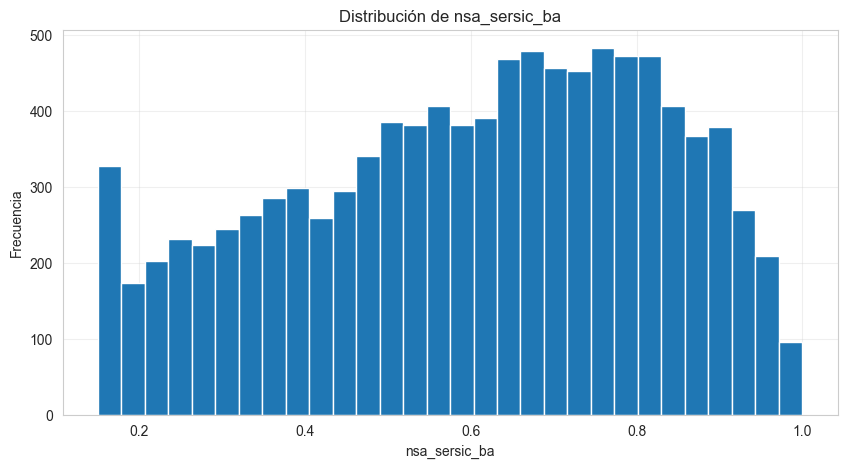

In [25]:
plt.figure(figsize=(10,5))

plt.hist(
    ba.dropna(),
    bins=30
)

plt.xlabel("nsa_sersic_ba")
plt.ylabel("Frecuencia")
plt.title("Distribución de nsa_sersic_ba")
plt.grid(alpha=0.3)

plt.show()

Para este experimento se seleccionaron galaxias con:

nsa_sersic_ba >= 0.70

Este umbral permite conservar una cantidad suficiente de observaciones para entrenamiento, mientras se priorizan galaxias observadas con menor efecto de proyección.

In [26]:
BA_THRESHOLD = 0.65

df_front = df_clean.copy()
df_front["nsa_sersic_ba"] = df_front["nsa_sersic_ba"].replace(-9999, np.nan)

df_front = df_front[
    df_front["nsa_sersic_ba"].notna() &
    (df_front["nsa_sersic_ba"] >= BA_THRESHOLD)
].copy()

print("Galaxias seleccionadas con nsa_sersic_ba >= 0.70:")
print(df_front.shape)
print(df_front["nsa_sersic_ba"].describe())

Galaxias seleccionadas con nsa_sersic_ba >= 0.70:
(4707, 17)
count    4707.0000
mean        0.7977
std         0.0900
min         0.6500
25%         0.7222
50%         0.7921
75%         0.8695
max         1.0000
Name: nsa_sersic_ba, dtype: float64


In [27]:
# CONSTRUCCIÓN DEL DATASET SUPERVISADO PARA LogMass
# Relación imagen <-> variable objetivo mediante 'name'
# Dataset filtrado por nsa_sersic_ba usando imágenes petro

target_col = "LogMass"

# Mantener únicamente las galaxias seleccionadas por orientación
front_names = df_front["name"].unique()

df_logmass = df_transformed[
    df_transformed["name"].isin(front_names)
][["name", target_col]].copy()

df_logmass = df_logmass.dropna(subset=[target_col])

# Agregar nsa_sersic_ba original solo para trazabilidad/análisis
df_logmass = df_logmass.merge(
    df_clean[["name", "nsa_sersic_ba"]],
    on="name",
    how="left"
)

# Ruta de imágenes petro
image_dir = Path(r"/Users/gustavomorales/Desktop/ITESM_MNA/Proyecto integrador/Imagenes_petro")

df_logmass["image_path"] = df_logmass["name"].apply(lambda x: image_dir / f"{x}.jpg")
df_logmass["image_exists"] = df_logmass["image_path"].apply(lambda p: p.exists())

print("Total registros con BA >= threshold:", len(df_logmass))
print("Imagenes encontradas:              ", df_logmass["image_exists"].sum())
print("Imagenes faltantes:                ", (~df_logmass["image_exists"]).sum())

df_logmass = df_logmass[df_logmass["image_exists"]].copy()
df_logmass = df_logmass[["name", target_col, "nsa_sersic_ba", "image_path"]].copy()

print("\nResumen nsa_sersic_ba en dataset final:")
print(df_logmass["nsa_sersic_ba"].describe())

# TRAIN / VALIDATION / TEST SPLIT
train_df, temp_df = train_test_split(
    df_logmass,
    test_size=0.30,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("\nShape dataset LogMass filtrado:", df_logmass.shape)
print("Train:     ", train_df.shape)
print("Validation:", val_df.shape)
print("Test:      ", test_df.shape)

print("\nRango de nsa_sersic_ba:")
print(f"Min: {df_logmass['nsa_sersic_ba'].min():.3f}")
print(f"Max: {df_logmass['nsa_sersic_ba'].max():.3f}")

Total registros con BA >= threshold: 4707
Imagenes encontradas:               4645
Imagenes faltantes:                 62

Resumen nsa_sersic_ba en dataset final:
count    4645.0000
mean        0.7976
std         0.0900
min         0.6500
25%         0.7220
50%         0.7920
75%         0.8696
max         1.0000
Name: nsa_sersic_ba, dtype: float64

Shape dataset LogMass filtrado: (4645, 4)
Train:      (3251, 4)
Validation: (697, 4)
Test:       (697, 4)

Rango de nsa_sersic_ba:
Min: 0.650
Max: 1.000


In [28]:
# PARAMETROS GLOBALES Y FUNCIONES DE CARGA DE IMAGENES

IMG_SIZE   = (224, 224)   # Compatible con todos los modelos
BATCH_SIZE = 16           # Consistente con Avance 3

def load_image_regression(image_path, target):
    """
    Carga, decodifica, redimensiona y normaliza una imagen JPEG.

    Parameters
    ----------
    image_path : tf.string
    target     : tf.float32  valor objetivo normalizado (LogMass)

    Returns
    -------
    image  : tf.Tensor shape (224, 224, 3) float32, valores en [0, 1]
    target : tf.float32
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, target


def create_dataset(dataframe, shuffle=True):
    """
    Construye un tf.data.Dataset desde un DataFrame con rutas de imagenes.

    Parameters
    ----------
    dataframe : pd.DataFrame  columnas 'image_path' y target_col
    shuffle   : bool

    Returns
    -------
    dataset : tf.data.Dataset
    """
    image_paths = dataframe["image_path"].astype(str).values
    targets     = dataframe[target_col].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    dataset = dataset.map(load_image_regression, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df,   shuffle=False)
test_ds  = create_dataset(test_df,  shuffle=False)

print("Datasets creados exitosamente.")

Datasets creados exitosamente.


In [29]:
# Heredada del Avance 3; calcula MAE, RMSE, R2, Scatter, Bias

def evaluate_regression_complete(y_true, y_pred, variable_name='LogMass'):
    """
    Evalua un modelo de regresion con metricas astronomicas completas.

    Parameters
    ----------
    y_true        : array-like  valores reales
    y_pred        : array-like  valores predichos
    variable_name : str

    Returns
    -------
    dict : R2, MAE, RMSE, MSE, Scatter, Bias, RMSE_MAE_ratio, Categoria
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae      = mean_absolute_error(y_true, y_pred)
    mse      = mean_squared_error(y_true, y_pred)
    rmse     = np.sqrt(mse)
    r2       = r2_score(y_true, y_pred)
    residuals = y_true - y_pred
    scatter   = np.std(residuals)
    bias      = np.mean(residuals)
    rmse_mae  = rmse / mae if mae > 0 else np.inf

    print(f"Metricas de Regresion para {variable_name}:")
    print(f"  R2 Score:        {r2:.4f}  ({r2*100:.2f}% varianza explicada)")
    print(f"  MAE:             {mae:.4f} dex")
    print(f"  RMSE:            {rmse:.4f} dex")
    print(f"  MSE:             {mse:.4f} dex2")
    print(f"  Scatter (sigma): {scatter:.4f} dex")
    print(f"  Bias:            {bias:+.4f} dex")
    print(f"  RMSE/MAE ratio:  {rmse_mae:.2f}")
    print()

    mae_f = 10 ** mae; scat_f = 10 ** scatter
    print("Interpretacion fisica (escala lineal):")
    print(f"  Error promedio (MAE):   {mae_f:.2f}x")
    print(f"  Dispersion tipica:      +/-{scat_f:.2f}x")
    print(f"  Rango de error tipico:  [{1/mae_f:.2f}x, {mae_f:.2f}x]")
    if   abs(bias) < 0.05: print("  Sin sesgo sistematico significativo (bias ~ 0)")
    elif bias > 0:         print(f"  Sesgo positivo: modelo subestima ({bias:+.4f} dex)")
    else:                  print(f"  Sesgo negativo: modelo sobreestima ({bias:+.4f} dex)")
    print()

    if   r2 >= 0.90: cat, desc = "EXCELENTE", "Modelo de alta precision"
    elif r2 >= 0.80: cat, desc = "MUY BUENO", "Baseline fuerte"
    elif r2 >= 0.70: cat, desc = "BUENO",     "Desempeno aceptable"
    elif r2 >= 0.50: cat, desc = "REGULAR",   "Mejora requerida"
    else:            cat, desc = "INACEPTABLE","Modelo no viable"

    print(f"Evaluacion cualitativa: {cat} - {desc}")
    print()
    print("Diagnostico de errores:")
    if   rmse_mae > 2.0: print(f"  ADVERTENCIA: RMSE/MAE={rmse_mae:.2f} - outliers severos")
    elif rmse_mae > 1.5: print(f"  NOTA: RMSE/MAE={rmse_mae:.2f} - algunos errores grandes")
    else:                print(f"  RMSE/MAE={rmse_mae:.2f} - distribucion normal, sin outliers extremos")

    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
            'Scatter': scatter, 'Bias': bias,
            'RMSE_MAE_ratio': rmse_mae, 'Categoria': cat}



# Funciones auxiliares de entrenamiento y visualizacion


def get_predictions(model, dataset):
    """Obtiene predicciones y etiquetas reales de un tf.data.Dataset."""
    y_true_list, y_pred_list = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(preds.flatten())
    return np.array(y_true_list), np.array(y_pred_list)


def train_model(model, train_ds, val_ds, epochs=30, patience=7):
    """
    Entrena un modelo Keras con EarlyStopping y ReduceLROnPlateau.

    Parameters
    ----------
    model    : tf.keras.Model  (ya compilado)
    train_ds, val_ds : tf.data.Dataset
    epochs   : int
    patience : int  paciencia EarlyStopping

    Returns
    -------
    history : tf.keras.callbacks.History
    elapsed : float  segundos totales
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
    start   = time.time()
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs, callbacks=callbacks, verbose=1)
    elapsed = time.time() - start
    print(f"\nTiempo de entrenamiento: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    return history, elapsed


def plot_training_curves(history, model_name):
    """Grafica curvas de perdida (MSE) y MAE de entrenamiento/validacion."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   lw=2)
    axes[0].set_title(f'Curva de Perdida (MSE) - {model_name}')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['mae'],     label='Train MAE', lw=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE',   lw=2)
    axes[1].set_title(f'Curva de MAE - {model_name}')
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('MAE (dex)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_combined_history(h1, h2, model_name):
    """
    Grafica curvas de dos fases de entrenamiento (feature extraction + fine-tuning)
    unificadas con linea vertical separadora.
    Retorna el total de epocas ejecutadas.
    """
    sep   = len(h1.history['loss'])
    loss  = h1.history['loss']     + h2.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss']
    mae   = h1.history['mae']      + h2.history['mae']
    vmae  = h1.history['val_mae']  + h2.history['val_mae']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, y, yv, ylabel, title in [
        (axes[0], loss, vloss, 'MSE',       f'Curva de Perdida - {model_name}'),
        (axes[1], mae,  vmae,  'MAE (dex)', f'Curva de MAE - {model_name}')
    ]:
        ax.plot(y,  label='Train', lw=2)
        ax.plot(yv, label='Val',   lw=2)
        ax.axvline(x=sep, color='red', ls='--', alpha=0.7, label='Inicio Fine-Tuning')
        ax.set_title(title); ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return len(loss)


# Registro global de resultados
results_registry = {}

print("Funciones utilitarias definidas correctamente.")

Funciones utilitarias definidas correctamente.


# Modelo 0 Baseline

In [30]:
from tensorflow.keras import layers, models

# DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

model_logmass0 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="linear")
])

model_logmass0.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
model_logmass0.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_logmass0 = model_logmass0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)
time_m0 = time.time() - start_time
model_logmass0.save("models_sersic_ba/M0_CNN_Baseline_sersic_ba.keras")

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 0.6208 - mae: 0.6213 - val_loss: 0.4495 - val_mae: 0.5478 - learning_rate: 0.0010
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.4260 - mae: 0.5010 - val_loss: 0.4313 - val_mae: 0.5202 - learning_rate: 0.0010
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.4064 - mae: 0.4875 - val_loss: 0.3347 - val_mae: 0.4546 - learning_rate: 0.0010
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.3693 - mae: 0.4573 - val_loss: 0.2718 - val_mae: 0.3973 - learning_rate: 0.0010
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - loss: 0.3611 - mae: 0.4528 - val_loss: 0.4057 - val_mae: 0.5091 - learning_rate: 0.0010
Epoch 6/20
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.3420 - mae: 0.4403
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.3330 - mae: 0.4334 - val_loss: 0.2937 - val_mae: 0.4298 - learning

In [32]:
print("\nEVALUACION EN TEST SET - Modelo 0\n")

y_test_m0, y_pred_m0 = get_predictions(model_logmass0, test_ds)

metrics_m0 = evaluate_regression_complete(
    y_test_m0, 
    y_pred_m0, 
    "LogMass"
)

metrics_m0.update({
    'Params': model_logmass0.count_params(),
    'Train_Time_s': time_m0,
    'Epochs_Run': len(history_logmass0.history['loss'])
})

results_registry["M0_Baseline_CNN"] = metrics_m0

print("\nMetricas CNN Baseline:")
print(f"  R2:   {metrics_m0['R2']:.4f}")
print(f"  MAE:  {metrics_m0['MAE']:.4f} dex")
print(f"  RMSE: {metrics_m0['RMSE']:.4f} dex")


EVALUACION EN TEST SET - Modelo 0

Metricas de Regresion para LogMass:
  R2 Score:        0.7612  (76.12% varianza explicada)
  MAE:             0.3789 dex
  RMSE:            0.4933 dex
  MSE:             0.2433 dex2
  Scatter (sigma): 0.4872 dex
  Bias:            +0.0776 dex
  RMSE/MAE ratio:  1.30

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   2.39x
  Dispersion tipica:      +/-3.07x
  Rango de error tipico:  [0.42x, 2.39x]
  Sesgo positivo: modelo subestima (+0.0776 dex)

Evaluacion cualitativa: BUENO - Desempeno aceptable

Diagnostico de errores:
  RMSE/MAE=1.30 - distribucion normal, sin outliers extremos

Metricas CNN Baseline:
  R2:   0.7612
  MAE:  0.3789 dex
  RMSE: 0.4933 dex


In [33]:
model_logmass0.save("models_sersic_ba/M0_CNN_Baseline_sersic_ba.keras")

np.save("predictions_sersic_ba/M0_y_test.npy", y_test_m0)
np.save("predictions_sersic_ba/M0_y_pred_test.npy", y_pred_m0)

y_test_m0_real = inverse_logmass_scaled(y_test_m0)
y_pred_m0_real = inverse_logmass_scaled(y_pred_m0.flatten())

y_val_m0, y_pred_val_m0 = get_predictions(model_logmass0, val_ds)
np.save("predictions_sersic_ba/M0_y_val.npy", y_val_m0)
np.save("predictions_sersic_ba/M0_y_pred_val.npy", y_pred_val_m0)

___
# Modelo 1. CNN con mejores hiperparametros

Mejores parametros (busqueda manual): {'dropout_rate': 0.4, 'dense_units': 256, 'learning_rate': 0.001}
Mejor val_mae: 0.4826

In [34]:
# MODELO 1: CNN Custom Baseline con arquitectura parametrizada

data_aug_m1 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
], name="aug_m1")

def build_cnn_baseline(dropout_rate=0.4, dense_units=128, learning_rate=1e-3):

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_aug_m1(inputs)

    x = layers.Conv2D(32,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="CNN_Baseline_Tuned")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


# Version con los mejores hiperparametros encontrados con Gridsearch en la actividad anterior

best_params_m1 = {
    "dropout_rate": 0.4,
    "dense_units": 256,
    "learning_rate": 0.001
}

model_logmass1 = build_cnn_baseline(**best_params_m1)
model_logmass1.summary()

Model: "CNN_Baseline_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_m1 (Sequential)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,529 (494.25 KB)

 Trainable params: 126,529 (494.25 KB)

 Non-trainable params: 0 (0.00 B)

ENTRENAMIENTO FINAL: CNN Baseline con HPs optimizados
Epoch 1/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.9937 - mae: 0.8368 - val_loss: 0.8139 - val_mae: 0.7540 - learning_rate: 0.0010
Epoch 2/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.8650 - mae: 0.7552 - val_loss: 0.7047 - val_mae: 0.6584 - learning_rate: 0.0010
Epoch 3/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.7451 - mae: 0.6899 - val_loss: 0.8652 - val_mae: 0.6997 - learning_rate: 0.0010
Epoch 4/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 0.6646 - mae: 0.6480 - val_loss: 0.5922 - val_mae: 0.6008 - learning_rate: 0.0010
Epoch 5/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.5904 - mae: 0.6091 - val_loss: 0.5597 - val_mae: 0.5930 - learning_rate: 0.0010
Epoch 6/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 0.5320 - mae: 0.5701 - val_loss: 0.4897 - val_mae: 0.5708 - learning_rate: 0.0010
Epoch 7/30
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.5051 - mae: 0.5508

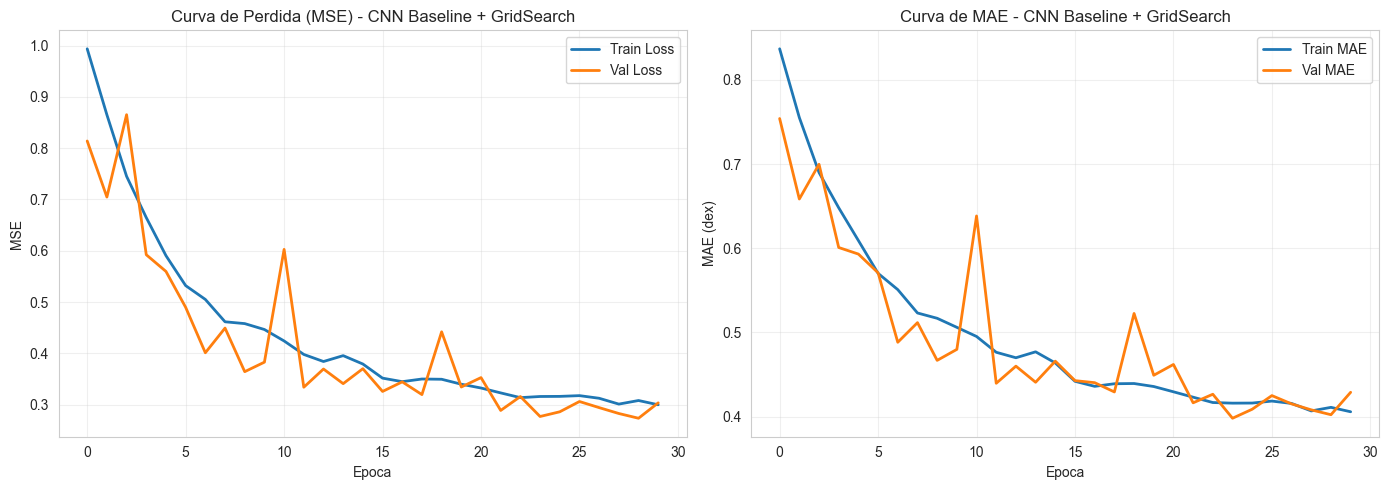

In [35]:
# Entrenamiento final - Modelo 1 con hiperparametros optimos
print("ENTRENAMIENTO FINAL: CNN Baseline con HPs optimizados")

start_time = time.time()
history_logmass1, time_m1 = train_model(model_logmass1, train_ds, val_ds, epochs=30, patience=7)
plot_training_curves(history_logmass1, "CNN Baseline + GridSearch")

time_m1 = time.time() - start_time
model_logmass1.save("models_sersic_ba/M1_CNN_Tuned_sersic_ba.keras")

In [36]:
print("\nEVALUACION EN TEST SET - Modelo 1\n")

y_test_m1, y_pred_m1 = get_predictions(model_logmass1, test_ds)

y_test_m1_real = inverse_logmass_scaled(y_test_m1)
y_pred_m1_real = inverse_logmass_scaled(y_pred_m1.flatten())

metrics_m1 = evaluate_regression_complete(
    y_test_m1, 
    y_pred_m1, 
    "LogMass"
)

metrics_m1.update({
    'Params': model_logmass1.count_params(),
    'Train_Time_s': time_m1,
    'Epochs_Run': len(history_logmass1.history['loss'])
})

results_registry["M1_Baseline_Tunned"] = metrics_m1

print("\nMetricas CNN Tuned:")
print(f"  R2:   {metrics_m1['R2']:.4f}")
print(f"  MAE:  {metrics_m1['MAE']:.4f} dex")
print(f"  RMSE: {metrics_m1['RMSE']:.4f} dex")


EVALUACION EN TEST SET - Modelo 1

Metricas de Regresion para LogMass:
  R2 Score:        0.6844  (68.44% varianza explicada)
  MAE:             0.4301 dex
  RMSE:            0.5671 dex
  MSE:             0.3215 dex2
  Scatter (sigma): 0.5556 dex
  Bias:            +0.1136 dex
  RMSE/MAE ratio:  1.32

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   2.69x
  Dispersion tipica:      +/-3.59x
  Rango de error tipico:  [0.37x, 2.69x]
  Sesgo positivo: modelo subestima (+0.1136 dex)

Evaluacion cualitativa: REGULAR - Mejora requerida

Diagnostico de errores:
  RMSE/MAE=1.32 - distribucion normal, sin outliers extremos

Metricas CNN Tuned:
  R2:   0.6844
  MAE:  0.4301 dex
  RMSE: 0.5671 dex


In [37]:
model_logmass1.save("models_sersic_ba/M1_CNN_Tuned_sersic_ba.keras")

np.save("predictions_sersic_ba/M1_y_test.npy", y_test_m1)
np.save("predictions_sersic_ba/M1_y_pred_test.npy", y_pred_m1)

y_val_m1, y_pred_val_m1 = get_predictions(model_logmass1, val_ds)
np.save("predictions_sersic_ba/M1_y_val.npy", y_val_m1)
np.save("predictions_sersic_ba/M1_y_pred_val.npy", y_pred_val_m1)

___

# Modelo 2. ResNet

In [38]:
# MODELO 2: ResNet-like Custom (bloques residuales desde cero)
# Algoritmo diferente al CNN plano del baseline

def residual_block(x, filters, stride=1):
    """
    Bloque residual estandar con conexion de identidad.

    Si filters o stride cambian, proyecta el shortcut con Conv1x1
    para mantener compatibilidad dimensional.

    Parameters
    ----------
    x       : tf.Tensor  tensor de entrada
    filters : int        filtros del bloque
    stride  : int        stride de la primera convolucion

    Returns
    -------
    tf.Tensor
    """
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet_custom(dropout_rate=0.3, dense_units=128, learning_rate=1e-3):
    """
    Arquitectura tipo ResNet entrenada desde cero.

    Arquitectura
    ------------
    Input(224,224,3) -> Augmentation
    -> Conv7x7(64, stride=2) -> BN -> ReLU -> MaxPool(3x3, stride=2)
    -> ResBlock(64) x 2
    -> ResBlock(128, stride=2) -> ResBlock(128)
    -> ResBlock(256, stride=2) -> ResBlock(256)
    -> GlobalAveragePooling2D
    -> Dense(dense_units, relu) -> Dropout(dropout_rate)
    -> Dense(1, linear)

    Parameters
    ----------
    dropout_rate  : float
    dense_units   : int
    learning_rate : float

    Returns
    -------
    model : tf.keras.Model compilado
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    # Stem
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Grupos residuales
    for filters, stride in [(64,1),(64,1),(128,2),(128,1),(256,2),(256,1)]:
        x = residual_block(x, filters, stride)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="ResNet_Custom")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


model_logmass2 = build_resnet_custom()
model_logmass2.summary()

Model: "ResNet_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_3   │ (None, 224, 224,  │          0 │ random_flip_3[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_3       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │      9,472 │ random_zoom_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 56, 56,    │     36,928 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_12[0][0] 

 Total params: 2,822,529 (10.77 MB)

 Trainable params: 2,818,049 (10.75 MB)

 Non-trainable params: 4,480 (17.50 KB)

ENTRENAMIENTO: ResNet-like Custom
Epoch 1/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 62s 280ms/step - loss: 0.7441 - mae: 0.6481 - val_loss: 1.9884 - val_mae: 1.2279 - learning_rate: 0.0010
Epoch 2/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 57s 275ms/step - loss: 0.5054 - mae: 0.5458 - val_loss: 1.9100 - val_mae: 1.1781 - learning_rate: 0.0010
Epoch 3/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 57s 273ms/step - loss: 0.4728 - mae: 0.5325 - val_loss: 0.6356 - val_mae: 0.6280 - learning_rate: 0.0010
Epoch 4/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 57s 274ms/step - loss: 0.4510 - mae: 0.5186 - val_loss: 0.7546 - val_mae: 0.7307 - learning_rate: 0.0010
Epoch 5/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 58s 279ms/step - loss: 0.4341 - mae: 0.5010 - val_loss: 0.3737 - val_mae: 0.4751 - learning_rate: 0.0010
Epoch 6/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 58s 282ms/step - loss: 0.4145 - mae: 0.4882 - val_loss: 0.4212 - val_mae: 0.5050 - learning_rate: 0.0010
Epoch 7/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 57s 274ms/step - loss: 0.4493 - mae: 0.5074 - val_loss: 

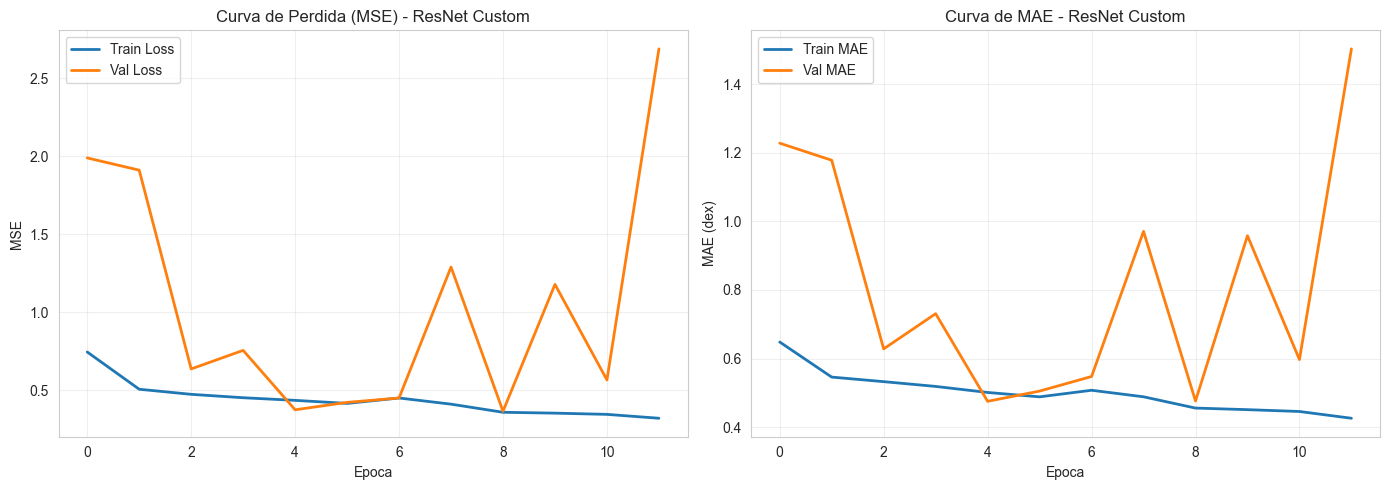


EVALUACION EN TEST SET - Modelo 2

Metricas de Regresion para LogMass:
  R2 Score:        0.5945  (59.45% varianza explicada)
  MAE:             0.5122 dex
  RMSE:            0.6428 dex
  MSE:             0.4131 dex2
  Scatter (sigma): 0.5977 dex
  Bias:            +0.2365 dex
  RMSE/MAE ratio:  1.25

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   3.25x
  Dispersion tipica:      +/-3.96x
  Rango de error tipico:  [0.31x, 3.25x]
  Sesgo positivo: modelo subestima (+0.2365 dex)

Evaluacion cualitativa: REGULAR - Mejora requerida

Diagnostico de errores:
  RMSE/MAE=1.25 - distribucion normal, sin outliers extremos


In [39]:
print("ENTRENAMIENTO: ResNet-like Custom")

history_logmass2, time_m2 = train_model(model_logmass2, train_ds, val_ds, epochs=12, patience=8)
plot_training_curves(history_logmass2, "ResNet Custom")

print("\nEVALUACION EN TEST SET - Modelo 2\n")
y_test_m2, y_pred_m2 = get_predictions(model_logmass2, test_ds)
metrics_m2 = evaluate_regression_complete(y_test_m2, y_pred_m2, "LogMass")
metrics_m2.update({'Params': model_logmass2.count_params(),
                   'Train_Time_s': time_m2,
                   'Epochs_Run': len(history_logmass2.history['loss'])})
results_registry["M2_ResNet_Custom"] = metrics_m2

In [40]:
y_test_m2, y_pred_m2 = get_predictions(model_logmass2, test_ds)

metrics_m2 = evaluate_regression_complete(
    y_test_m2,
    y_pred_m2,
    "LogMass"
)

metrics_m2.update({
    "Params": model_logmass2.count_params(),
    "Train_Time_s": time_m2,
    "Epochs_Run": len(history_logmass2.history["loss"])
})

results_registry["M2_ResNet_Custom"] = metrics_m2

Metricas de Regresion para LogMass:
  R2 Score:        0.5945  (59.45% varianza explicada)
  MAE:             0.5122 dex
  RMSE:            0.6428 dex
  MSE:             0.4131 dex2
  Scatter (sigma): 0.5977 dex
  Bias:            +0.2365 dex
  RMSE/MAE ratio:  1.25

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   3.25x
  Dispersion tipica:      +/-3.96x
  Rango de error tipico:  [0.31x, 3.25x]
  Sesgo positivo: modelo subestima (+0.2365 dex)

Evaluacion cualitativa: REGULAR - Mejora requerida

Diagnostico de errores:
  RMSE/MAE=1.25 - distribucion normal, sin outliers extremos


In [41]:
model_logmass2.save("models_sersic_ba/M2_ResNet_Custom.keras")

np.save("predictions_sersic_ba/M2_y_test.npy", y_test_m2)
np.save("predictions_sersic_ba/M2_y_pred_test.npy", y_pred_m2)

y_val_m2, y_pred_val_m2 = get_predictions(model_logmass2, val_ds)

np.save("predictions_sersic_ba/M2_y_val.npy", y_val_m2)
np.save("predictions_sersic_ba/M2_y_pred_val.npy", y_pred_val_m2)

___
# Modelo 3. EfficientNetB0

In [42]:
# MODELO 3: EfficientNetB0 + Transfer Learning

def build_efficientnet_b0(dense_units=256, dropout_rate=0.4, freeze_layers=30):
    """
    EfficientNetB0 preentrenado en ImageNet con cabeza de regresion.

    Estrategia de dos fases:
        Fase 1 - Feature extraction (base congelada)
        Fase 2 - Fine-tuning de las ultimas freeze_layers capas

    Parameters
    ----------
    dense_units   : int
    dropout_rate  : float
    freeze_layers : int   capas a descongelar en fine-tuning

    Returns
    -------
    model      : tf.keras.Model
    base_model : tf.keras.Model  (referencia para fine-tuning)
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    base_model = EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=x
    )
    base_model.trainable = False  # Fase 1: congelado

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs,
                         name="EfficientNetB0_TL")
    return model, base_model

# MODELO 3: EfficientNetB0 + Transfer Learning

best_params_m3 = {
    "dense_units": 512,
    "dropout_rate": 0.4,
    "freeze_layers": 50
}

model_logmass3, base_model3 = build_efficientnet_b0(**best_params_m3)

model_logmass3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

print(f"Total parametros: {model_logmass3.count_params():,}")

Total parametros: 4,740,388


In [43]:
# FASE 1: feature extraction

start_time = time.time()

history_logmass3_phase1 = model_logmass3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# FASE 2: fine-tuning
base_model3.trainable = True

for layer in base_model3.layers[:-best_params_m3["freeze_layers"]]:
    layer.trainable = False

model_logmass3.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="mse",
    metrics=["mae"]
)

history_logmass3_phase2 = model_logmass3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

time_m3 = time.time() - start_time

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - loss: 1.4104 - mae: 0.9700 - val_loss: 1.4275 - val_mae: 1.0343 - learning_rate: 0.0010
Epoch 2/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.2088 - mae: 0.9113
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 1.1573 - mae: 0.8944 - val_loss: 1.0312 - val_mae: 0.8214 - learning_rate: 0.0010
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 1.0757 - mae: 0.8743 - val_loss: 0.9686 - val_mae: 0.8228 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - loss: 1.6781 - mae: 1.0360 - val_loss: 0.9672 - val_mae: 0.8242 - learning_rate: 1.0000e-05
Epoch 2/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 1.5435 - mae: 1.0102
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
204/204 ━━━━━━━━━━━━━━━━━━

In [44]:
y_test_m3, y_pred_m3 = get_predictions(model_logmass3, test_ds)

metrics_m3 = evaluate_regression_complete(
    y_test_m3,
    y_pred_m3,
    "LogMass"
)

epochs_m3 = (
    len(history_logmass3_phase1.history["loss"]) +
    len(history_logmass3_phase2.history["loss"])
)

metrics_m3.update({
    "Params": model_logmass3.count_params(),
    "Train_Time_s": time_m3,
    "Epochs_Run": epochs_m3,
    "Best_Params": str(best_params_m3)
})

results_registry["M3_EfficientNetB0"] = metrics_m3

Metricas de Regresion para LogMass:
  R2 Score:        -0.0106  (-1.06% varianza explicada)
  MAE:             0.8504 dex
  RMSE:            1.0148 dex
  MSE:             1.0297 dex2
  Scatter (sigma): 1.0093 dex
  Bias:            -0.1051 dex
  RMSE/MAE ratio:  1.19

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   7.09x
  Dispersion tipica:      +/-10.22x
  Rango de error tipico:  [0.14x, 7.09x]
  Sesgo negativo: modelo sobreestima (-0.1051 dex)

Evaluacion cualitativa: INACEPTABLE - Modelo no viable

Diagnostico de errores:
  RMSE/MAE=1.19 - distribucion normal, sin outliers extremos


In [45]:
model_logmass3.save("models_sersic_ba/M3_EfficientNetB0.keras")

np.save("predictions_sersic_ba/M3_y_test.npy", y_test_m3)
np.save("predictions_sersic_ba/M3_y_pred_test.npy", y_pred_m3)

y_val_m3, y_pred_val_m3 = get_predictions(model_logmass3, val_ds)

np.save("predictions_sersic_ba/M3_y_val.npy", y_val_m3)
np.save("predictions_sersic_ba/M3_y_pred_val.npy", y_pred_val_m3)

___
# Visualizar resultados

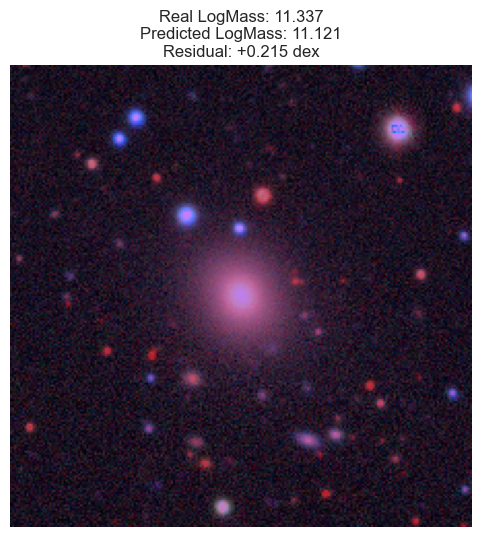

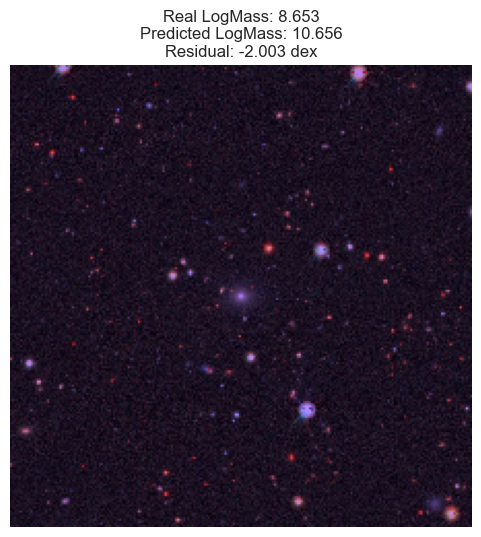

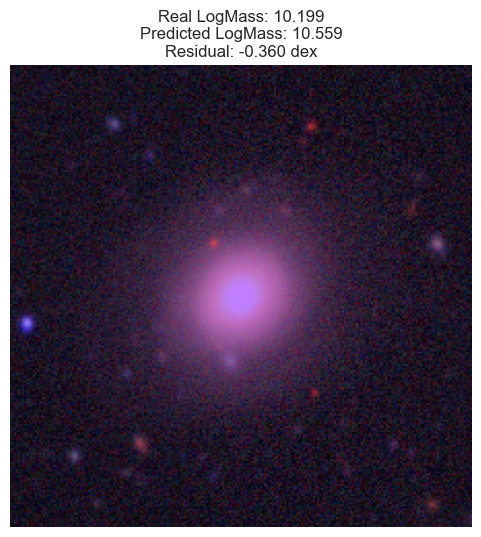

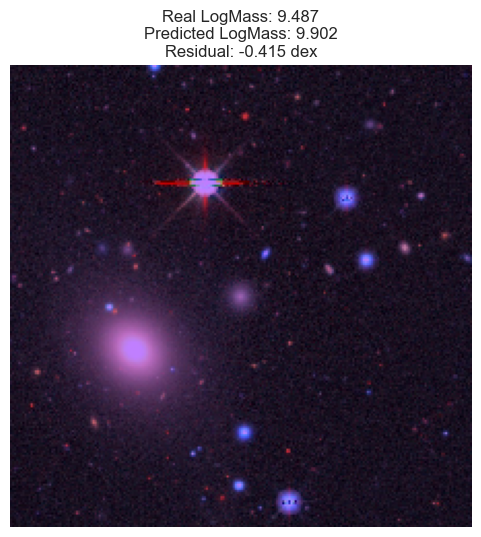

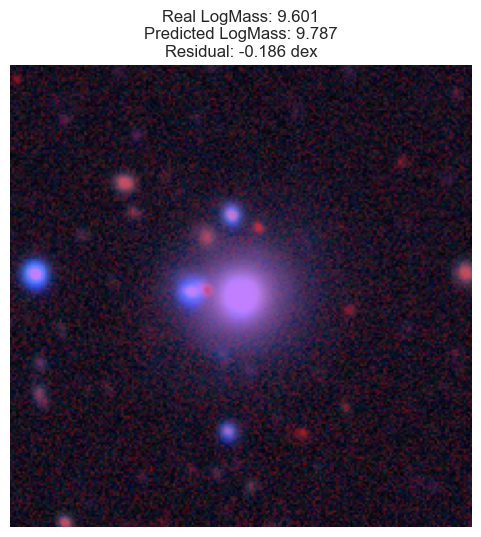

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

for i in range(5):

    # SELECCIONAR UNA MUESTRA ALEATORIA
    sample_row = test_df.sample(1).iloc[0]
    img_path = sample_row["image_path"]

    # Valor real ESCALADO
    real_logmass_scaled = sample_row[target_col]

    # Convertir a LogMass REAL
    real_logmass = inverse_logmass_scaled(real_logmass_scaled)

    # CARGAR Y PREPROCESAR IMAGEN
    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # Agregar dimensión batch
    img_input = np.expand_dims(img_array, axis=0)

    # PREDICCIÓN DEL MODELO (ESCALADA)
    pred_logmass_scaled = model_logmass0.predict(
        img_input,
        verbose=0
    )[0][0]

    # Convertir predicción a escala real
    pred_logmass = inverse_logmass_scaled(pred_logmass_scaled)

    # Error físico
    error_dex = real_logmass - pred_logmass

    # VISUALIZACIÓN
    plt.figure(figsize=(6,6))
    plt.imshow(img_array)

    plt.title(
        f"Real LogMass: {real_logmass:.3f}\n"
        f"Predicted LogMass: {pred_logmass:.3f}\n"
        f"Residual: {error_dex:+.3f} dex"
    )

    plt.axis("off")
    plt.show()